In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder , StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer , KNNImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix

In [109]:
df=pd.read_csv("heart_disease_uci.csv")

In [110]:
from sklearn.model_selection import train_test_split
X=df.drop(['num','id'],axis=1)
Y=df['num']

In [111]:
# Train-Test Splitting the data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [112]:
# outliers

In [113]:
Q1=X_train['trestbps'].quantile(0.25)
Q3=X_train['trestbps'].quantile(0.75)
iqr=Q3-Q1
upper=Q3+(1.5 * iqr)
lower=Q1-(1.5 * iqr)
X_train['trestbps']=X_train['trestbps'].clip(lower=lower,upper=upper)
X_test['trestbps']=X_test['trestbps'].clip(lower=lower,upper=upper)

In [114]:
mean_chol=X_train['chol'].mean()
std_chol=X_train['chol'].std()
lower=mean_chol - 3*std_chol
upper=mean_chol + 3*std_chol
X_train['chol'][(X_train['chol']>upper) | (X_train['chol']<lower)].count()


train_df=X_train.copy()
train_df['out']=Y_train
train_df=train_df[(train_df['chol']>=lower) & (train_df['chol']<=upper)]
X_train=train_df.drop(columns=['out'])
Y_train=train_df['out']

X_test['chol'] = X_test['chol'].clip(lower=lower, upper=upper)



In [115]:
mean_thalch=X_train['thalch'].mean()
std_thalch=X_train['thalch'].std()
lower=mean_thalch - 3*std_thalch
upper=mean_thalch + 3*std_thalch
X_train['thalch'][(X_train['thalch']>upper) | (X_train['thalch']<lower)].count()

np.int64(1)

In [116]:
# missing values

In [117]:
X_train.isnull().mean()*100

age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.872370
chol         0.000000
fbs         10.238429
restecg      0.280505
thalch       6.311360
exang        6.311360
oldpeak      7.012623
slope       31.837307
ca          65.217391
thal        51.472651
dtype: float64

In [118]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 753 to 873
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       713 non-null    int64  
 1   sex       713 non-null    str    
 2   dataset   713 non-null    str    
 3   cp        713 non-null    str    
 4   trestbps  664 non-null    float64
 5   chol      713 non-null    float64
 6   fbs       640 non-null    object 
 7   restecg   711 non-null    str    
 8   thalch    668 non-null    float64
 9   exang     668 non-null    object 
 10  oldpeak   663 non-null    float64
 11  slope     486 non-null    str    
 12  ca        248 non-null    float64
 13  thal      346 non-null    str    
dtypes: float64(5), int64(1), object(2), str(6)
memory usage: 116.0+ KB


In [119]:
# missing indicator

X_train['slope_missing']=X_train['slope'].isnull().astype(int)
X_test['slope_missing']=X_test['slope'].isnull().astype(int)

X_train['ca_missing']=X_train['ca'].isnull().astype(int)
X_test['ca_missing']=X_test['ca'].isnull().astype(int)

X_train['thal_missing']=X_train['thal'].isnull().astype(int)
X_test['thal_missing']=X_test['thal'].isnull().astype(int)

X_train.drop(columns=['ca','thal'],inplace=True)
X_test.drop(columns=['ca','thal'],inplace=True)

In [120]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 753 to 873
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            713 non-null    int64  
 1   sex            713 non-null    str    
 2   dataset        713 non-null    str    
 3   cp             713 non-null    str    
 4   trestbps       664 non-null    float64
 5   chol           713 non-null    float64
 6   fbs            640 non-null    object 
 7   restecg        711 non-null    str    
 8   thalch         668 non-null    float64
 9   exang          668 non-null    object 
 10  oldpeak        663 non-null    float64
 11  slope          486 non-null    str    
 12  slope_missing  713 non-null    int64  
 13  ca_missing     713 non-null    int64  
 14  thal_missing   713 non-null    int64  
dtypes: float64(4), int64(4), object(2), str(5)
memory usage: 117.7+ KB


In [121]:
X_train.drop(columns=['dataset'],inplace=True)
X_test.drop(columns=['dataset'],inplace=True)

In [122]:
X_train['slope'].value_counts()

slope
flat           275
upsloping      164
downsloping     47
Name: count, dtype: int64

In [123]:
# ordinal :  slope
# nominal : exang restecg cp sex fbs


# knn needs numerical values , encoding needs no nan values so use float in encoding so it kind of ignores nan

ode=OrdinalEncoder(categories=[['upsloping','flat','downsloping']],dtype=float,handle_unknown='use_encoded_value',unknown_value=np.nan,encoded_missing_value=np.nan)  # using float  nan stays nan
X_train['slope']=ode.fit_transform(X_train[['slope']])
X_test['slope']=ode.transform(X_test[['slope']])

In [124]:
print(X_train['slope'].isnull().sum())

227


In [125]:
df.isnull().mean()*100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

In [126]:
# nominal : exang restecg fbs

In [127]:


# exang has 6% missing values
si_exang=SimpleImputer(strategy='most_frequent')
X_train['exang']=si_exang.fit_transform(X_train[['exang']]).ravel()   # returns 2D array
X_test['exang']=si_exang.transform(X_test[['exang']]).ravel()

# restecg has 0.2% missing values
si_restecg=SimpleImputer(strategy='most_frequent')
X_train['restecg']=si_restecg.fit_transform(X_train[['restecg']]).ravel()
X_test['restecg']=si_restecg.transform(X_test[['restecg']]).ravel()

si_fbs=SimpleImputer(strategy='most_frequent')
X_train['fbs']=si_fbs.fit_transform(X_train[['fbs']]).ravel()
X_test['fbs']=si_fbs.transform(X_test[['fbs']]).ravel()


In [128]:
X_train.isnull().mean()*100

age               0.000000
sex               0.000000
cp                0.000000
trestbps          6.872370
chol              0.000000
fbs               0.000000
restecg           0.000000
thalch            6.311360
exang             0.000000
oldpeak           7.012623
slope            31.837307
slope_missing     0.000000
ca_missing        0.000000
thal_missing      0.000000
dtype: float64

In [129]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 753 to 873
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            713 non-null    int64  
 1   sex            713 non-null    str    
 2   cp             713 non-null    str    
 3   trestbps       664 non-null    float64
 4   chol           713 non-null    float64
 5   fbs            713 non-null    object 
 6   restecg        713 non-null    str    
 7   thalch         668 non-null    float64
 8   exang          713 non-null    object 
 9   oldpeak        663 non-null    float64
 10  slope          486 non-null    float64
 11  slope_missing  713 non-null    int64  
 12  ca_missing     713 non-null    int64  
 13  thal_missing   713 non-null    int64  
dtypes: float64(5), int64(4), object(2), str(3)
memory usage: 102.2+ KB


In [130]:
X_train.isnull().sum()

age                0
sex                0
cp                 0
trestbps          49
chol               0
fbs                0
restecg            0
thalch            45
exang              0
oldpeak           50
slope            227
slope_missing      0
ca_missing         0
thal_missing       0
dtype: int64

In [131]:

encode_cols=['exang','restecg','cp','sex','fbs']
ohe=OneHotEncoder(drop='first',sparse_output=False)

xtrain_encoded=ohe.fit_transform(X_train[encode_cols])
xtest_encoded=ohe.transform(X_test[encode_cols])

xtrain_encoded_df=pd.DataFrame(xtrain_encoded,columns=ohe.get_feature_names_out(encode_cols),index=X_train.index)
xtest_encoded_df=pd.DataFrame(xtest_encoded,columns=ohe.get_feature_names_out(encode_cols),index=X_test.index)

X_train.drop(columns=encode_cols,inplace=True)
X_test.drop(columns=encode_cols,inplace=True)

X_train=pd.concat([X_train,xtrain_encoded_df],axis=1)
X_test=pd.concat([X_test,xtest_encoded_df],axis=1)


In [132]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 753 to 873
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       713 non-null    int64  
 1   trestbps                  664 non-null    float64
 2   chol                      713 non-null    float64
 3   thalch                    668 non-null    float64
 4   oldpeak                   663 non-null    float64
 5   slope                     486 non-null    float64
 6   slope_missing             713 non-null    int64  
 7   ca_missing                713 non-null    int64  
 8   thal_missing              713 non-null    int64  
 9   exang_True                713 non-null    float64
 10  restecg_normal            713 non-null    float64
 11  restecg_st-t abnormality  713 non-null    float64
 12  cp_atypical angina        713 non-null    float64
 13  cp_non-anginal            713 non-null    float64
 14  cp_typical angina       

In [133]:
X_train.isnull().sum()

age                           0
trestbps                     49
chol                          0
thalch                       45
oldpeak                      50
slope                       227
slope_missing                 0
ca_missing                    0
thal_missing                  0
exang_True                    0
restecg_normal                0
restecg_st-t abnormality      0
cp_atypical angina            0
cp_non-anginal                0
cp_typical angina             0
sex_Male                      0
fbs_True                      0
dtype: int64

In [134]:

impute=KNNImputer(n_neighbors=5)
X_train=pd.DataFrame(
    impute.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test=pd.DataFrame(
    impute.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [135]:
scale_cols=['age','trestbps','chol','thalch','oldpeak','slope']

scaler=StandardScaler()
X_train[scale_cols]=scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]=scaler.transform(X_test[scale_cols])

In [136]:
print(Y_train.value_counts(normalize=True)*100)

out
0    43.338008
1    29.453015
2    12.201964
3    11.500701
4     3.506311
Name: proportion, dtype: float64


In [137]:
# no missing values
print(X_train.isnull().sum().sum())  
print(X_test.isnull().sum().sum())   


print(X_train.shape)
print(X_test.shape)


print(X_train.dtypes.unique()) 

0
0
(713, 17)
(184, 17)
[dtype('float64')]


In [138]:
print(X_train.shape)
print(X_test.shape)

(713, 17)
(184, 17)


In [139]:
sm=SMOTE(random_state=42)
X_train_bal,Y_train_bal=sm.fit_resample(X_train,Y_train)

In [140]:
lr=LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [141]:
lr.fit(X_train_bal,Y_train_bal)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [142]:
Y_pred=lr.predict(X_test)

In [143]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78        89
           1       0.48      0.41      0.44        49
           2       0.26      0.30      0.28        20
           3       0.38      0.42      0.40        24
           4       0.05      0.50      0.09         2

    accuracy                           0.54       184
   macro avg       0.41      0.47      0.40       184
weighted avg       0.63      0.54      0.58       184



In [144]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[63 12  6  1  7]
 [ 6 20  8  9  6]
 [ 0  4  6  6  4]
 [ 3  6  2 10  3]
 [ 0  0  1  0  1]]


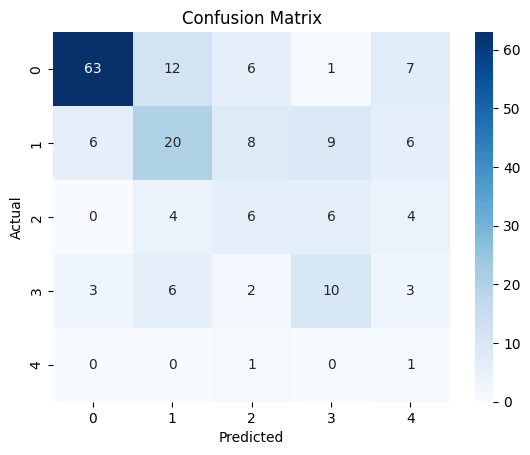

In [145]:
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()